In [64]:
import pandas as pd
from sklearn.datasets import load_iris
from scipy.spatial.distance import mahalanobis
import scipy as sp
from matplotlib import pyplot as plt
import seaborn as sns

sns.set()

Load Iris dataset

In [6]:
df, target = load_iris(return_X_y=True, as_frame=True)
df["label"] = target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [37]:
df0 = df[df["label"]==0]
df1 = df[df["label"]==1]
df2 = df[df["label"]==2]

Histogram for sepal length

(array([ 1.,  0.,  5.,  5.,  8.,  9., 10.,  5.,  1.,  6.]),
 array([4.9, 5.2, 5.5, 5.8, 6.1, 6.4, 6.7, 7. , 7.3, 7.6, 7.9]),
 <a list of 10 Patch objects>)

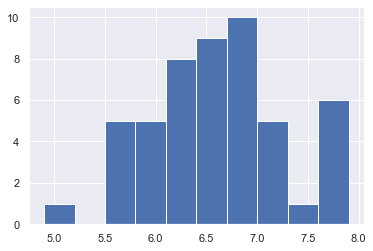

In [73]:
plt.hist(df2["sepal length (cm)"])

Tukey's Fences method. No outliers found.

In [74]:
# Tukey's Fences, below Q1-1.5(Q3-Q1) or above Q3+1.5(Q3-Q1)
def print_outliers(func):
    for idx, _df in enumerate([df0, df1, df2]):
        print(f"For species {idx}:")
        print(func(_df, "sepal length (cm)"))
        print(func(_df, "sepal width (cm)"))
        print(func(_df, "petal length (cm)"))
        print(func(_df, "petal width (cm)"))
        print("\n")

def get_outliers_tf(df, col):
    q1 = df.quantile(0.25)[col]
    q3 = df.quantile(0.75)[col]
    low = q1 - 1.5 * (q3 - q1)
    high = q3 + 1.5 * (q3 - q1)
    df_out = df[(df[col]<low)&(df[col]>high)]
    return df_out

print_outliers(get_outliers_tf)

For species 0:
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []


For species 1:
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []


For species 2:
Empty DataFrame

Standard deviation method. No outliers found

In [75]:
# standard deviation
def get_outliers_std(df, col):
    mean = df[col].mean()
    std = df[col].std()
    low = mean - 3 * std
    high = mean + 3 * std
    df_out = df[(df[col]<low)&(df[col]>high)]
    return df_out

print_outliers(get_outliers_std)

For species 0:
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []


For species 1:
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []


For species 2:
Empty DataFrame

Mean aboslute deviation method. No outliers found.

In [76]:
# mean absolute deviation
def get_outliers_mad(df, col):
    df_copy = df.copy()
    median = df[col].median()
    df_copy["diff"] = (df_copy[col] - median).abs()
    median2 = df_copy["diff"].median()
    low = median - 3 * median2
    high = median + 3 * median2
    df_out = df[(df[col]<low)&(df[col]>high)]
    return df_out

print_outliers(get_outliers_mad)

For species 0:
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []


For species 1:
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), label]
Index: []


For species 2:
Empty DataFrame

Top Mahalanobis distances for the features

<BarContainer object of 5 artists>

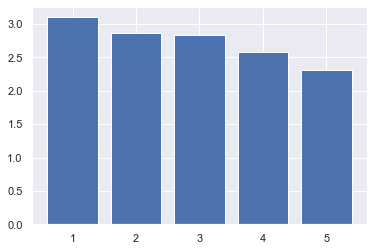

In [70]:
# Top Mahalanobis distance for [sepal length, petal length]
df_sl_pl = df[["sepal length (cm)", "petal length (cm)"]]
Sx = df_sl_pl.cov().values
Sx = sp.linalg.inv(Sx)
mean = df_sl_pl.mean().values
distances = []
for i in range(len(df_sl_pl)):
    distances.append(mahalanobis(df_sl_pl.iloc[i],mean,Sx))
top_distances = sorted(distances, reverse=True)[:5]
plt.bar(range(1, 6), height=top_distances)